Fáza 2 - Predspracovanie údajov

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer,
    QuantileTransformer,
    Normalizer,
    LabelEncoder
)
from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    mutual_info_regression,
    VarianceThreshold
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

path = Path("../data/cleaned_data")

observation_df = pd.read_csv(path / "observation.csv")
patient_df = pd.read_csv(path / "patient.csv")
station_df = pd.read_csv(path / "station.csv")

In [2]:
station_df["revision"] = pd.to_datetime(station_df["revision"], errors="coerce")
station_df["revision"] = station_df["revision"].astype("int64") // 10**9  

le = LabelEncoder()
for col in ["station", "continent", "city", "QoS"]:
    if col in station_df.columns:
        station_df[col] = station_df[col].fillna("Missing")
        station_df[col] = le.fit_transform(station_df[col].astype(str))

display(station_df.head())

,station,longitude,QoS,latitude,revision,continent,city
0,224,86.51499,2,23.19590,1529193600,4,57
1,72,-83.48216,2,42.30865,1665360000,1,32
2,513,84.87144,2,47.46657,1478390400,4,4
3,415,30.38167,2,59.80917,1662768000,6,81
4,85,2.95924,2,36.76775,1704585600,0,3


In [3]:
merged_df = pd.merge(
    observation_df,
    station_df,
    on=["latitude", "longitude"],
    how="left"
)

Non-null station data: 100.0 %


In [4]:
X = merged_df.drop('oximetry', axis=1)
y = merged_df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(17260, 27) (4315, 27)


In [ ]:
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

scaled_results = {}

for name, scaler in scalers.items():
    scaler.fit(X_train)
    X_scaled = scaler.transform(X_train)
    scaled_results[name] = X_scaled

    print(f"\n{name}:")
    print(f"  Mean: {X_scaled.mean():.6f}")
    print(f"  Std:  {X_scaled.std():.6f}")
    print(f"  Min:  {X_scaled.min():.6f}")
    print(f"  Max:  {X_scaled.max():.6f}")

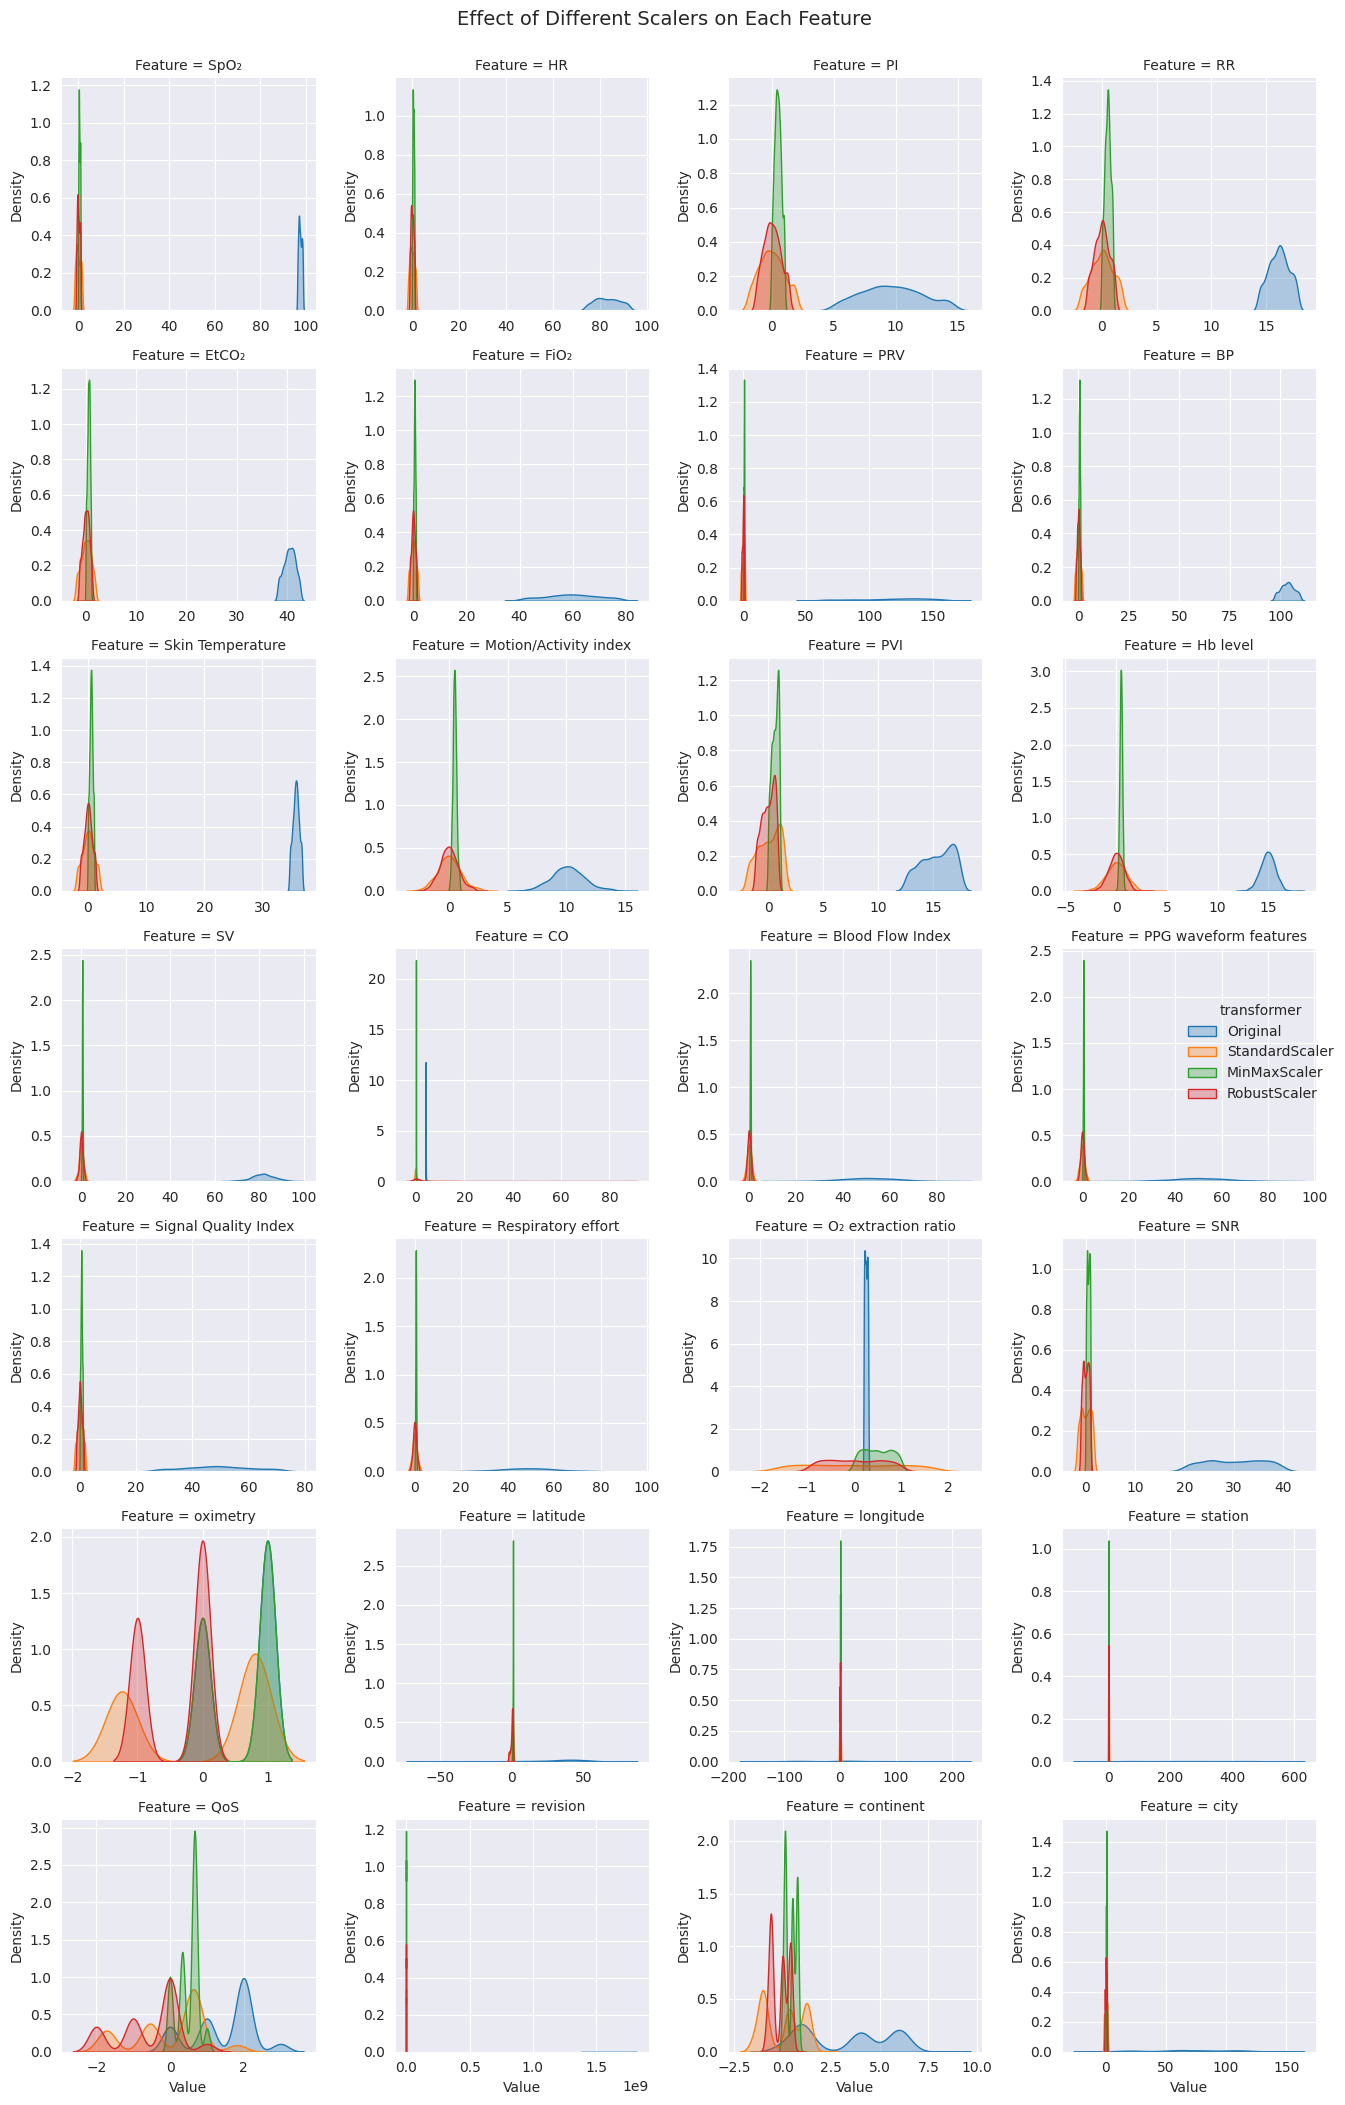

In [5]:
нарисуй граф до после

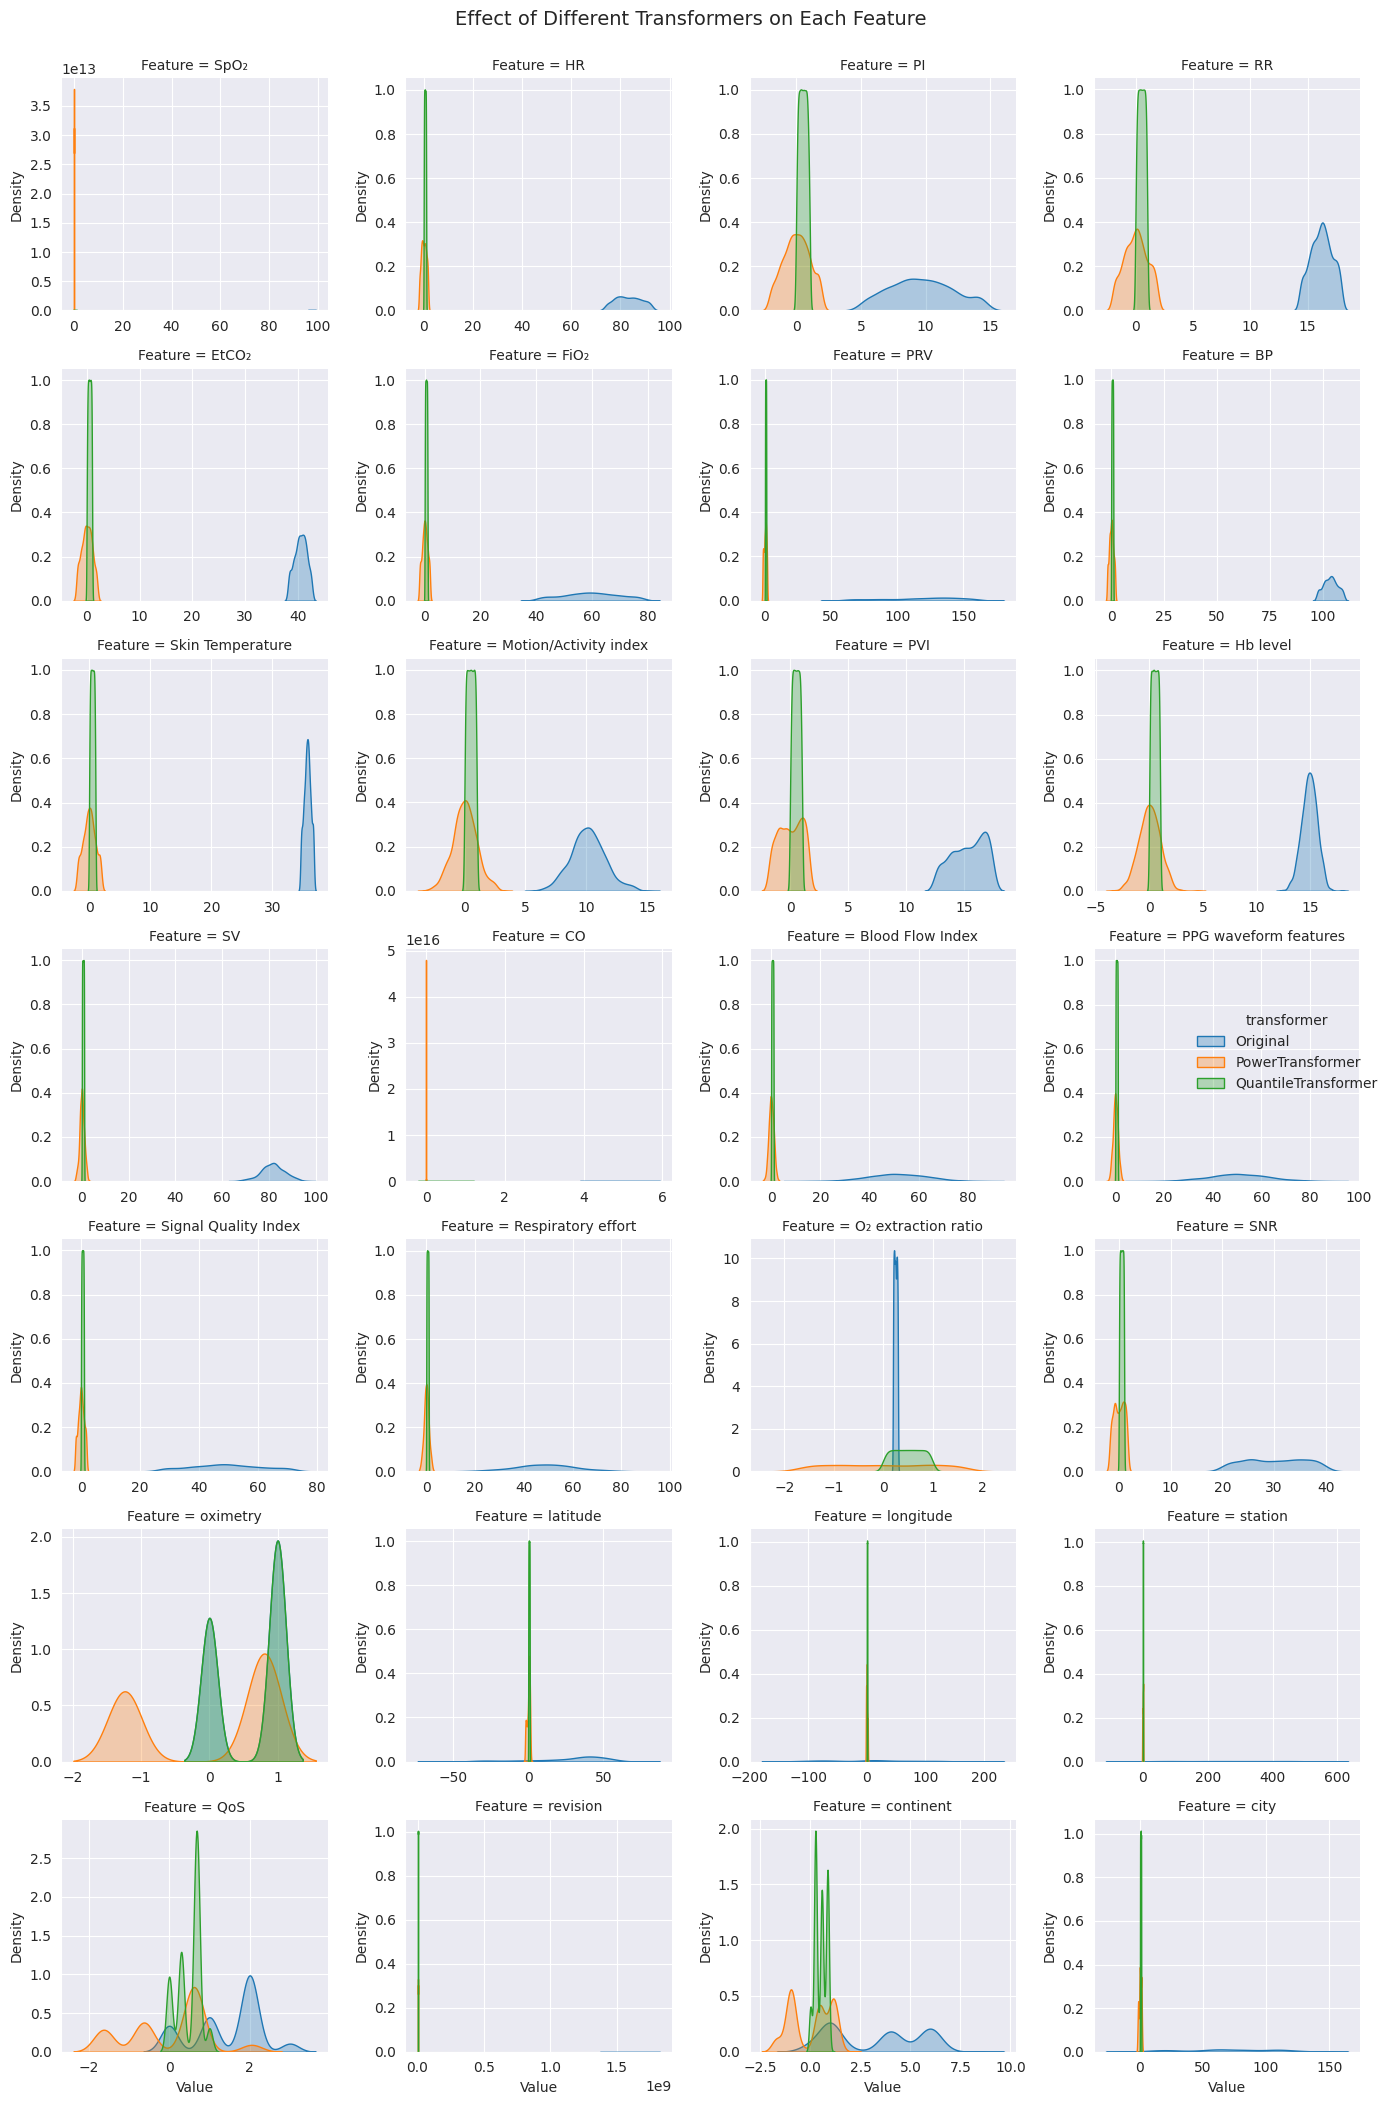

In [6]:
transformers = {
    "PowerTransformer": PowerTransformer(),
    "QuantileTransformer": QuantileTransformer(n_quantiles=100, random_state=42),
}

transformed_results = {}

for name, transformer in transformers.items():
    transformed.fit(X_train)
    X_transformed = transformer.transform(X_train)

    transformed_results[name] = X_transformed

In [ ]:
нарисуй граф до после

In [7]:
# Výpočet korelácií s target premennou
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("="*60)
print("TECHNIKA 1: KORELAČNÁ ANALÝZA")
print("="*60)
print("\nTop 10 atribútov podľa absolútnej korelácie s oximetry:\n")
print(correlations.head(10))

# Vizualizácia
plt.figure(figsize=(12, 6))
correlations.head(15).plot(kind='barh')
plt.xlabel('Absolútna korelácia s oximetry')
plt.title('Top 15 features podľa korelácie')
plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Uloženie výsledkov
correlation_ranking = correlations.to_dict()

,Scaler,Selector,R2 Score,MAE
6,PowerTransformer,SelectKBest,0.900240,0.069103
0,StandardScaler,SelectKBest,0.899773,0.069404
3,RobustScaler,SelectKBest,0.899757,0.069402
9,QuantileTransformer,SelectKBest,0.898791,0.069650
5,RobustScaler,VarianceThreshold,0.880439,0.081319
2,StandardScaler,VarianceThreshold,0.880419,0.081326
11,QuantileTransformer,VarianceThreshold,0.880268,0.081346
10,QuantileTransformer,MutualInfo,0.878972,0.078148
1,StandardScaler,MutualInfo,0.878627,0.078146
4,RobustScaler,MutualInfo,0.878627,0.078146


In [ ]:
# SelectKBest s f_regression
from sklearn.feature_selection import SelectKBest, f_regression

selector_f = SelectKBest(score_func=f_regression, k='all')
selector_f.fit(X_train, y_train)

# Získanie scores
f_scores = pd.Series(selector_f.scores_, index=X_train.columns).sort_values(ascending=False)

print("\n" + "="*60)
print("TECHNIKA 2: SelectKBest (F-regression)")
print("="*60)
print("\nTop 10 atribútov podľa F-score:\n")
print(f_scores.head(10))

# Vizualizácia
plt.figure(figsize=(12, 6))
f_scores.head(15).plot(kind='barh')
plt.xlabel('F-score')
plt.title('Top 15 features podľa F-regression')
plt.tight_layout()
plt.savefig('f_regression_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Uloženie výsledkov
f_regression_ranking = f_scores.to_dict()

In [ ]:
# Mutual Information
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("\n" + "="*60)
print("TECHNIKA 3: Mutual Information")
print("="*60)
print("\nTop 10 atribútov podľa MI score:\n")
print(mi_scores.head(10))

# Vizualizácia
plt.figure(figsize=(12, 6))
mi_scores.head(15).plot(kind='barh', color='green')
plt.xlabel('Mutual Information Score')
plt.title('Top 15 features podľa Mutual Information')
plt.tight_layout()
plt.savefig('mutual_info_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Uloženie výsledkov
mi_ranking = mi_scores.to_dict()

In [ ]:
# Random Forest Feature Importance
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\n" + "="*60)
print("TECHNIKA 4: Random Forest Feature Importance")
print("="*60)
print("\nTop 10 atribútov podľa RF importance:\n")
print(rf_importance.head(10))

# Vizualizácia
plt.figure(figsize=(12, 6))
rf_importance.head(15).plot(kind='barh', color='orange')
plt.xlabel('Feature Importance')
plt.title('Top 15 features podľa Random Forest')
plt.tight_layout()
plt.savefig('rf_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Uloženie výsledkov
rf_ranking = rf_importance.to_dict()

In [ ]:
# Normalizácia scores pre porovnanie
def normalize_scores(scores_dict):
    """Normalizuje scores do rozsahu [0, 1]"""
    scores = pd.Series(scores_dict)
    return (scores - scores.min()) / (scores.max() - scores.min())

# Normalizácia všetkých ranking metód
norm_corr = normalize_scores(correlation_ranking)
norm_f = normalize_scores(f_regression_ranking)
norm_mi = normalize_scores(mi_ranking)
norm_rf = normalize_scores(rf_ranking)

# Vytvorenie dataframe so všetkými scores
feature_scores = pd.DataFrame({
    'Correlation': norm_corr,
    'F-regression': norm_f,
    'Mutual_Info': norm_mi,
    'Random_Forest': norm_rf
})

# Výpočet priemerného score
feature_scores['Mean_Score'] = feature_scores.mean(axis=1)
feature_scores['Rank'] = feature_scores['Mean_Score'].rank(ascending=False)

# Zoradenie podľa priemeru
feature_scores_sorted = feature_scores.sort_values('Mean_Score', ascending=False)

print("="*80)
print("FINÁLNE ZORADENIE ATRIBÚTOV")
print("="*80)
print("\nTop 15 najdôležitejších features:\n")
display(feature_scores_sorted.head(15).round(3))

# Uloženie do CSV
feature_scores_sorted.to_csv('feature_importance_rankings.csv')
print("\n✓ Výsledky uložené do 'feature_importance_rankings.csv'")

In [ ]:
# Vizualizácia porovnania všetkých metód
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Heatmapa top 15 features
top_15_features = feature_scores_sorted.head(15)
sns.heatmap(
    top_15_features[['Correlation', 'F-regression', 'Mutual_Info', 'Random_Forest', 'LASSO']].T,
    annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], cbar_kws={'label': 'Normalized Score'}
)
axes[0].set_title('Porovnanie feature importance metód (Top 15)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Metódy')

# Priemerné scores
top_15_features['Mean_Score'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Priemerný Normalized Score')
axes[1].set_title('Finálne zoradenie features (priemer všetkých metód)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Analýza zhody medzi metódami
print("\n" + "="*80)
print("ANALÝZA ZHODY MEDZI METÓDAMI")
print("="*80)

# Top 10 z každej metódy
top_k = 10
top_features = {
    'Correlation': set(feature_scores.nlargest(top_k, 'Correlation').index),
    'F-regression': set(feature_scores.nlargest(top_k, 'F-regression').index),
    'Mutual_Info': set(feature_scores.nlargest(top_k, 'Mutual_Info').index),
    'Random_Forest': set(feature_scores.nlargest(top_k, 'Random_Forest').index),
    'LASSO': set(feature_scores.nlargest(top_k, 'LASSO').index)
}

# Priesečník všetkých metód
common_features = set.intersection(*top_features.values())
print(f"\nFeatures v top-{top_k} VŠETKÝCH metód ({len(common_features)} features):")
print(sorted(common_features))

# Priesečník aspoň 4 metód
feature_counts = {}
for feature in set.union(*top_features.values()):
    count = sum(feature in features for features in top_features.values())
    feature_counts[feature] = count

robust_features = [f for f, c in feature_counts.items() if c >= 4]
print(f"\nFeatures v top-{top_k} aspoň 4 metód ({len(robust_features)} features):")
print(sorted(robust_features))

In [8]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_regression, k='all')),
    ('model', LinearRegression())
])

pipeline.fit(X_test, y_test)

selector = pipeline.named_steps['select']
mask = selector.get_support()
selected_features = X.columns[mask]

coef = pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': coef,
    'Abs_Coeff': abs(coef)
}).sort_values(by='Abs_Coeff', ascending=False)

display(coef_df.head(100))

,Feature,Coefficient,Abs_Coeff
10,PVI,0.261122,0.261122
6,PRV,0.095798,0.095798
1,HR,0.094183,0.094183
4,EtCO₂,-0.051433,0.051433
0,SpO₂,-0.023421,0.023421
26,city,0.008159,0.008159
25,continent,-0.007616,0.007616
18,O₂ extraction ratio,0.006560,0.006560
8,Skin Temperature,0.004601,0.004601
24,revision,0.004293,0.004293
